In [1]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import siglent_sds1104xe_oscope as scope_funcs

## Connect to the Oscilloscope

In [2]:
rm = pyvisa.ResourceManager()
oscope_ip = '192.168.1.2'
oscope = rm.open_resource(f'TCPIP0::{oscope_ip}::INSTR')
oscope.query('*IDN?')

'Siglent Technologies,SDS1104X-E,SDSMMFCX6R6004,8.3.6.1.37R8\n'

## Capture Channel Data

In [19]:
T, t1, data1 = scope_funcs.capture_data(oscope, 1)
T, t2, data2 = scope_funcs.capture_data(oscope, 2)

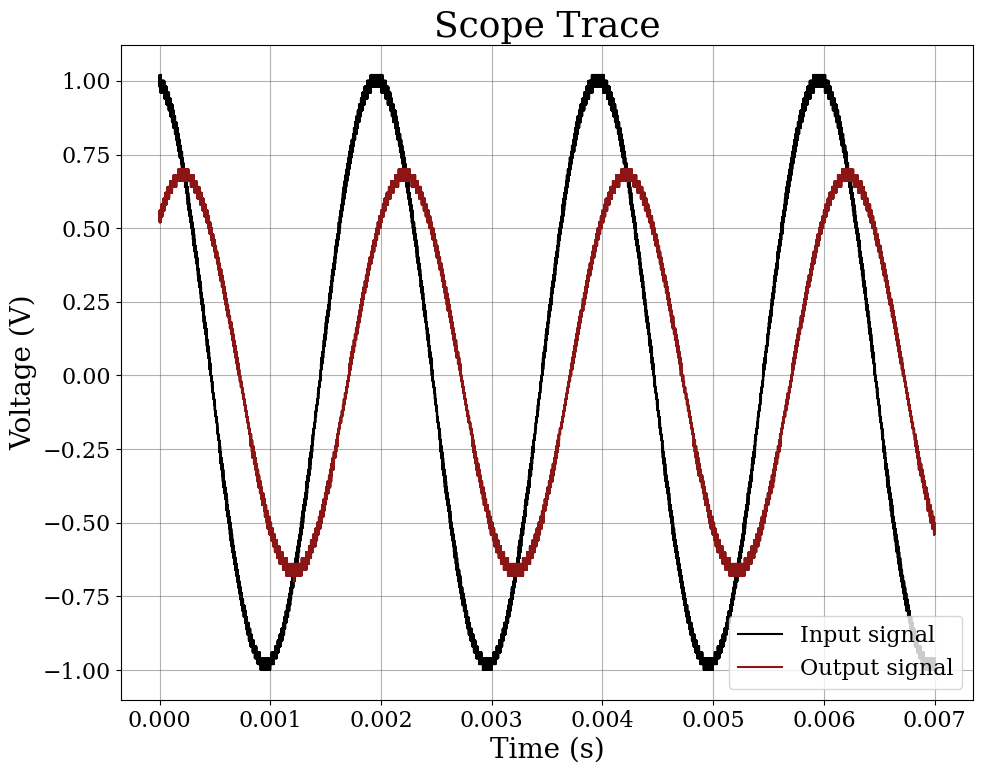

In [21]:
fig, ax = plt.subplots()

ax.set(xlabel='Time (s)', ylabel='Voltage (V)', title='Scope Trace')
ax.plot(t1, data1, label='Input signal')
ax.plot(t2, data2, label='Output signal')
ax.legend()
fig.savefig('SineWaveInputVOutput.pdf')

## Compute predicted output

Magnitude and phase response

In [5]:
R = 1e3
C = 330e-9
freqs = np.linspace(0, 2e3, 10000)

mag = 1 / np.sqrt((1 + (2*np.pi*freqs*R*C)**2))
phase = np.arctan(-2*np.pi*freqs*R*C)

Sine wave predicted output

In [6]:
f = 500
t = np.linspace(0, 10e-3, 10000)
f_index = np.argmin(abs(freqs - f))
rc_sin_output = mag[f_index] * np.cos((2*np.pi*f*t) + phase[f_index])

Square wave predicted output

In [8]:
def get_square_wave_rc_output(n, f, t, R, C):
    """ Compute the output of an RC filter to a square wave input.

    :param n: Number of terms in the series summation.
    :param f: Fundamental frequency of the square wave.
    :param t: Time vector.
    :param R: Resistance of the circuit.
    :param C: Capacitance of the circuit.
    """
    # - compute the magnitude and phase response of the circuit - #
    high_freq = (n+1)*f
    freqs = np.linspace(0, high_freq, t.shape[0])
    mag = 1 / np.sqrt((1 + (2*np.pi*freqs*R*C)**2))
    phase = np.arctan(-2*np.pi*freqs*R*C)
    
    # - compute and return the circuit output - #
    sig = (1/2) * np.ones_like(t)
    for k in range(1, n):
        freq = k*f
        freq_index = np.argmin(abs(freqs - freq))
        coef = np.sin(k * (np.pi / 2)) / (k * np.pi)
        cos = np.cos(k*2*np.pi*f*t + phase[freq_index])
        sig += (2 * coef * cos) * mag[freq_index]
    
    return sig

rc_square_output = get_square_wave_rc_output(100, 500, t, R, C)

## Plot predicted output against real circuit data

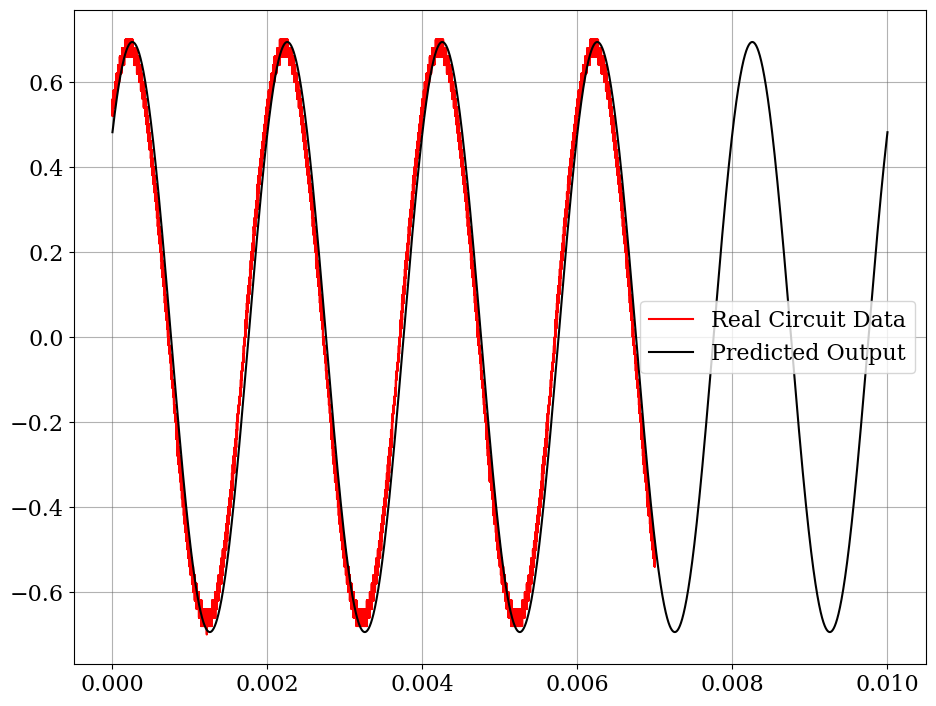

In [23]:
fig, ax = plt.subplots()

ax.plot(t2, data2, label='Real Circuit Data', c='red')
ax.plot(t, rc_sin_output, label='Predicted Output', c='black')
ax.legend()
fig.savefig('SinWaveComparison.pdf')